# Projet Python pour la data science (2026)

# Réalisé par Alix HÉRITIER et Ivan TISSOT

# Introduction

Nous partons des résultats du premier tour de l'élection présidentielle de 2022 disponibles sur data.gouv.fr. 

En prenant comme unités statistiques les départements de la France métropolitaine, nous souhaitons enrichir ces scores électoraux de données socio-économiques disponibles sur insee.fr.

Ensuite, sur les variables électorales, nous envisageons une ACP suivie d'une classification des départements (avec une clusterisation K-means).

Après avoir caractérisé électoralement les classes de départements établies, nous souhaitons savoir si ces classes ont leurs propres spécificités socio-économiques.

In [26]:
# Installation des librairies nécessaires
!pip install -r requirements.txt -q 

# Importation des librairies
import pandas as pd 
import openpyxl as openpyxl
import geopandas as gpd
from cartiflette import carti_download 
import io
import requests
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib import cm
import jinja2
import zipfile

# Importation des fonctions créées
from scripts.d_chomage import donnees_chomage
from scripts.d_cs import donnees_cs


# Importation des données électorales

Nous commencons par importer les données électorales 2022 disponibles sur data.gouv.fr. 

In [27]:
de = pd.read_csv('https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb')

/tmp/ipykernel_938/407956804.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  de = pd.read_csv('https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb')


In [28]:
# Vérification de la présence de données manquantes
print("Valeurs manquantes par colonne") 
print(de.isnull().sum())

# On veut voir quels sont les noms associés aux prénoms manquants
# Garder uniquement les lignes où le prénom est manquant
de_prenom_manquant = de[de['prenom'].isnull()]

# Affichage des noms associés aux prénoms manquants
print(f"Nombre de lignes avec prénom manquant : {len(de_prenom_manquant)}")
print("\nNoms associés aux prénoms manquants ")
print(de_prenom_manquant['nom'].value_counts())

# On constate que les noms associés aux prénoms manquants sont : "abstentions" ; "blancs" ; "nuls"
# Nous enlèverons ces données plus tard donc ces données manquantes ne sont pas problématiques pour le devoir maison ! 

Valeurs manquantes par colonne
code_departement            0
libelle_departement         0
code_commune                0
libelle_commune             0
prenom                 105735
nom                         0
voix                        0
dtype: int64
Nombre de lignes avec prénom manquant : 105735

Noms associés aux prénoms manquants 
nom
abstentions    35245
blancs         35245
nuls           35245
Name: count, dtype: int64


In [29]:
# On met les codes en texte avec le bon nombre de chiffres
de["code_departement"] = de["code_departement"].astype(str).str.zfill(2)

# On crée la colonne candidat = prénom + nom
de["prenom"] = de["prenom"].fillna("").astype(str).str.strip()
de["nom"] = de["nom"].fillna("").astype(str).str.strip()

de["candidat"] = de["prenom"] + " " + de["nom"]
de["candidat"] = de["candidat"].str.strip()


In [30]:
# On ne prend que les candidats ayant un prénom et un nom 
non_candidats = ["abstentions", "blancs", "nuls"]
de_candidats = de[de["candidat"].isin(non_candidats) == False]


In [31]:
# Calcul des votes par département et par candidat
scores_departementaux = (
    de_candidats.groupby(["code_departement", "candidat"], as_index=False)["voix"]
    .sum()
    .rename(columns={"voix": "votes_departemental"})
)

# Pivot : mettre les candidats en colonnes et les départements en lignes
scores_departementaux_pivot = scores_departementaux.pivot(index="code_departement", columns="candidat", values="votes_departemental")
# Enlever le nom 'candidat' des colonnes
scores_departementaux_pivot.columns.name = None

# Réinitialiser l'index pour remettre 'code_departement' comme colonne
scores_departementaux_pivot = scores_departementaux_pivot.reset_index()

scores_departementaux_pivot['somme'] = scores_departementaux_pivot.iloc[:, 1:13].sum(axis=1)
scores_departementaux_pivot = scores_departementaux_pivot.iloc[0:96, 0:14]
for col in scores_departementaux_pivot.columns:
    if col != 'somme' and col != 'code_departement':
        scores_departementaux_pivot[f's_{col}'] = scores_departementaux_pivot[col] / scores_departementaux_pivot['somme']
print(len(scores_departementaux_pivot.columns))

26


In [32]:
# Création des colonnes scores
dele = scores_departementaux_pivot
dele = dele.iloc[0:96, [0,14,15,16,17,18,19,20,21,22,23,24,25]]
new_column_names = ['code', 'HIDALGO', 'MACRON', 'ROUSSEL', 'LASSALLE', 'MELENCHON', 'LE PEN', 
                    'ARTHAUD', 'DUPONT-AIGNAN', 'POUTOU', 'PECRESSE', 'JADOT', 'ZEMMOUR']
dele.columns = new_column_names

# Importation des données sur le chômage
Nous importons ensuite les données sur le chômage et nous vérifions qu'elles sont complètes.

In [33]:
# Nous utilisons la fonction créée "donnees_chomage"
url = 'https://www.insee.fr/fr/statistiques/fichier/2134411/TCRD_087.xlsx'
dc = donnees_chomage(url)
dc["Taux_chomage_2024"] = pd.to_numeric(dc["Taux_chomage_2024"], errors="coerce")
dc.head(10)

# Vérification des types et valeurs
print(dc.dtypes)
dc.describe()

code                  object
Taux_chomage_2024    float64
dtype: object


,Taux_chomage_2024
count,96.000000
mean,7.109375
std,1.425562
min,4.200000
25%,6.200000
50%,6.900000
75%,7.700000
max,12.200000


# Importation des données suivantes:
- médiane du niveau vie (€)
- taux de pauvreté-Ensemble (%)
- rapport interdécile 9ᵉ décile/1ᵉʳ décile
- part des revenus dactivité
- part des ménages fiscaux imposés (%)

Nous faisons des vérifications de base sur les données pour vérifier qu'elles sont complètes.

In [34]:
url = 'https://www.insee.fr/fr/statistiques/fichier/6692392/base-cc-filosofi-2020_XLSX.zip'

# Téléchargement et lecture directe depuis le ZIP en mémoire
response = requests.get(url)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    print("Fichiers dans le ZIP :", z.namelist())  # remplace ton os.listdir
    with z.open('base-cc-filosofi-2020-geo2023.xlsx') as f:
        dme = pd.read_excel(f, sheet_name='DEP', decimal=',')

# Sélection et renommage des colonnes
dme = dme.iloc[5:101, [0, 4, 5, 6, 15, 28]]
dme = dme.rename(columns={
    dme.columns[0]: 'code',
    dme.columns[1]: 'Med_nivvie',
    dme.columns[2]: 'P_menfiscaux_imposes',
    dme.columns[3]: 'Tx_pauvrete',
    dme.columns[4]: 'P_rev_dactivite',
    dme.columns[5]: 'Rap_interdec'
})

# Conversion numérique
cols_numeriques = ['Med_nivvie', 'P_menfiscaux_imposes', 'Tx_pauvrete', 'P_rev_dactivite', 'Rap_interdec']
dme[cols_numeriques] = dme[cols_numeriques].apply(pd.to_numeric, errors='coerce')

dme.head(10)

#Vérification  que les données sont complètes et au bon format 

print(dme.dtypes)
print(dme.isnull().sum())
dme.describe()


Fichiers dans le ZIP : ['base-cc-filosofi-2020-geo2023.xlsx', 'base_cc_BDFDOM-2017.xlsx']


code                     object
Med_nivvie                int64
P_menfiscaux_imposes    float64
Tx_pauvrete             float64
P_rev_dactivite         float64
Rap_interdec            float64
dtype: object
code                    0
Med_nivvie              0
P_menfiscaux_imposes    0
Tx_pauvrete             0
P_rev_dactivite         0
Rap_interdec            0
dtype: int64


,Med_nivvie,P_menfiscaux_imposes,Tx_pauvrete,P_rev_dactivite,Rap_interdec
count,96.000000,96.000000,96.000000,96.000000,96.000000
mean,22052.187500,48.233333,14.335417,68.311458,3.131250
std,1649.147278,6.304012,2.937417,7.594941,0.481732
min,18470.000000,39.000000,8.900000,55.600000,2.500000
25%,20990.000000,43.675000,12.200000,63.200000,2.900000
50%,21665.000000,46.500000,14.200000,66.550000,3.000000
75%,22520.000000,51.500000,15.550000,71.875000,3.300000
max,28810.000000,69.600000,27.600000,92.300000,6.200000


# Importation des niveaux de diplôme
Nous vérifions, après leur importation, que les données sont fonctionnelles.

In [35]:
url = 'https://www.insee.fr/fr/statistiques/fichier/1893149/pop-16ans-dipl6822.zip'
response = requests.get(url)
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    print("Fichiers dans le ZIP :", z.namelist())
    with z.open('pop-16ans-dipl6822.xlsx') as f:
        dip = pd.read_excel(f, sheet_name='DEP_2022')
dip = dip.iloc[14:110, 1:32]
dip['P_infBac'] = dip.iloc[:, 2:18].sum(axis=1) / dip.iloc[:, 2:30].sum(axis=1)
dip['P_sup1erC'] = dip.iloc[:, 26:30].sum(axis=1) / dip.iloc[:, 2:30].sum(axis=1)
dip = dip.iloc[0:96, [0, 30, 31]]
dip = dip.rename(columns={
    dip.columns[0]: 'code',
    dip.columns[1]: 'P_infBac',
    dip.columns[2]: 'P_sup1erC'
})
cols_numeriques = ['P_infBac', 'P_sup1erC']
dip[cols_numeriques] = dip[cols_numeriques].apply(pd.to_numeric, errors='coerce')
dip.head(10)

#Vérification que les données sont complètes et au bon format
print(dip.dtypes)
print(dip.isnull().sum())
dip.describe()

Fichiers dans le ZIP : ['pop-16ans-dipl6822.xlsx']


code          object
P_infBac     float64
P_sup1erC    float64
dtype: object
code         0
P_infBac     0
P_sup1erC    0
dtype: int64


,P_infBac,P_sup1erC
count,96.000000,96.000000
mean,0.510833,0.190695
std,0.072656,0.073742
min,0.209318,0.101994
25%,0.476727,0.146670
50%,0.518741,0.174406
75%,0.563461,0.211489
max,0.624533,0.590082


# Importation des données sur les catégories socio-professionnelles (CS)
Nous importons les données CS et nous vérifions leur état.

In [36]:
# Utilisation de la fonction créée "donnees_cs"
url = 'https://www.insee.fr/fr/statistiques/fichier/2012721/TCRD_014.xlsx'
dcs = donnees_cs(url)
cols_numeriques = [
    'cs_agri',
    'cs_arti',
    'cs_cadr',
    'cs_inte',
    'cs_empl',
    'cs_ouvr'
]
dcs[cols_numeriques] = dcs[cols_numeriques].apply(pd.to_numeric, errors='coerce')
dcs.head(10)

#Vérification  que les données sont complètes et au bon format 

print(dcs.dtypes)
print(dcs.isnull().sum())
dcs.describe()

code        object
cs_agri    float64
cs_arti    float64
cs_cadr    float64
cs_inte    float64
cs_empl    float64
cs_ouvr    float64
dtype: object
code       0
cs_agri    0
cs_arti    0
cs_cadr    0
cs_inte    0
cs_empl    0
cs_ouvr    0
dtype: int64


,cs_agri,cs_arti,cs_cadr,cs_inte,cs_empl,cs_ouvr
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,2.001042,6.751042,14.557292,24.921875,27.750000,22.804167
std,1.681384,1.622473,6.662333,1.694151,2.468155,4.847417
min,0.000000,4.500000,8.100000,21.200000,17.300000,6.100000
25%,0.875000,5.400000,10.400000,23.850000,26.575000,20.550000
50%,1.750000,6.500000,12.800000,24.950000,27.700000,23.150000
75%,2.625000,7.925000,16.375000,26.125000,29.300000,26.475000
max,8.700000,10.900000,48.900000,28.500000,34.400000,31.100000


# Appariement des 5 tables sur les départements
Nous créons la base finale en assemblant les 5 tables importées précédemment.

In [37]:
# Fusionner dcs avec dip sur la colonne 'code'
base = pd.merge(dcs, dip, on='code', how='left')
base = pd.merge(base, dc, on='code', how='left')
base = pd.merge(base, dme, on='code', how='left')
base = pd.merge(base, dele, on='code', how='left')


Nous avons obtenu une table de données électorales et socio-économiques.
Cette table "base" comprend 27 variables pour les 96 départements de France métropolitaine:
- 1 variable de code département
- 6 variables de catégorie socio-professionnelle
- 2 variables de diplôme,
- 1 variable de chômage,
- 5 variables socio-économiques,
- 12 variables électorales

# Analyse des scores électoraux : ACP et K-means
Dans cette section, nous nous concentrons sur les variables électorales issues des résultats du premier tour de l'élection présidentielle de 2022. L'objectif est double : d'une part, identifier les principales dimensions structurant les comportements électoraux à l'échelle départementale à travers une Analyse en Composantes Principales (ACP), et d'autre part, construire une typologie des départements par classification K-means. Pour ce faire, nous produirons un éboulis des valeurs propres ainsi qu'un cercle des corrélations afin d'interpréter les axes factoriels, puis nous nous appuierons sur la méthode du coude et le score de silhouette pour justifier le choix du nombre de classes. Nous chercherons ensuite à caractériser électoralement les groupes obtenus, avant d'examiner dans quelle mesure ils se distinguent également sur le plan socio-économique.

In [38]:
base_elections = base.iloc[0:96, [0,15,16,17,18,19,20,21,22,23,24,25,26]]

/tmp/ipykernel_938/1577423129.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", k_opt)


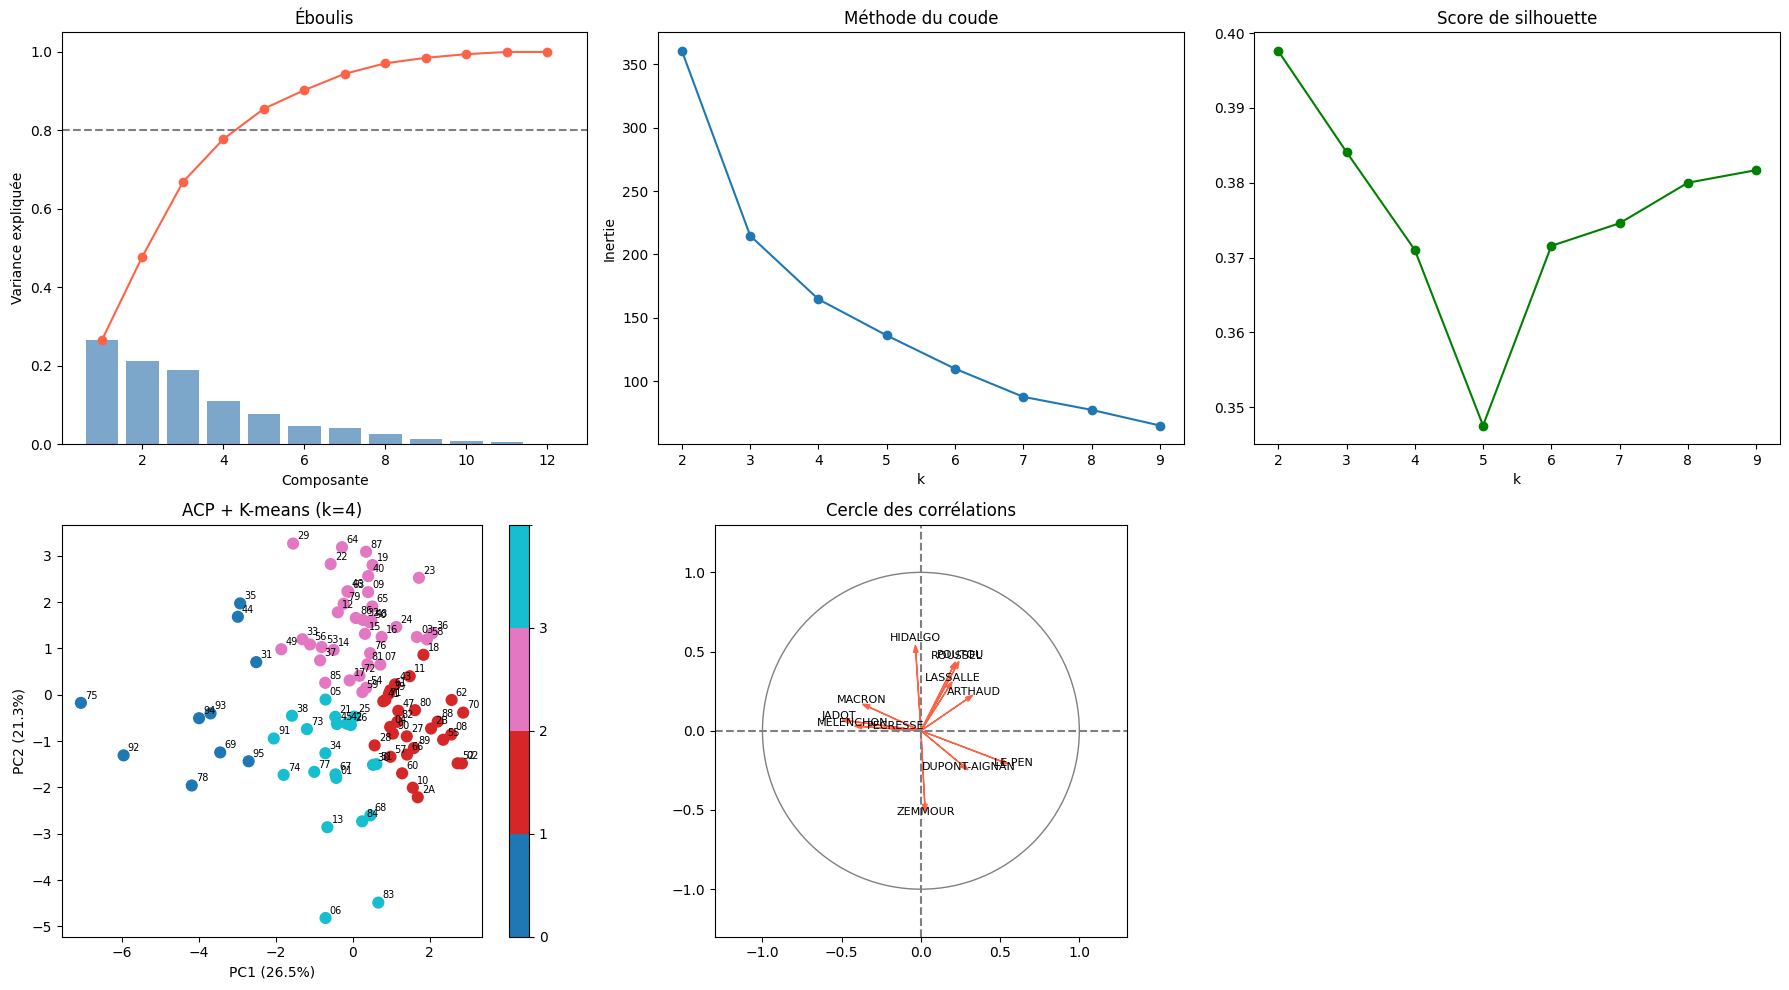

               Contrib PC1  Contrib PC2
LE PEN               0.258        0.037
JADOT                0.204        0.004
MELENCHON            0.140        0.001
MACRON               0.107        0.022
ARTHAUD              0.084        0.040
DUPONT-AIGNAN        0.069        0.047
POUTOU               0.048        0.159
ROUSSEL              0.039        0.156
LASSALLE             0.030        0.074
PECRESSE             0.019        0.000
HIDALGO              0.001        0.245
ZEMMOUR              0.001        0.215
         HIDALGO  MACRON  ROUSSEL  LASSALLE  MELENCHON  LE PEN  ARTHAUD  \
cluster                                                                   
0           0.02    0.31     0.02      0.02       0.29    0.14     0.00   
1           0.02    0.24     0.02      0.04       0.17    0.31     0.01   
2           0.02    0.28     0.03      0.05       0.19    0.24     0.01   
3           0.02    0.26     0.02      0.03       0.20    0.25     0.01   

         DUPONT-AIGNAN  POUTO

In [39]:
dept_labels = base_elections.iloc[:, 0].astype(str)
candidats = [c for c in base_elections.columns[1:] if c != "cluster"]

base_elections[candidats] = (
    base_elections[candidats]
    .replace(",", ".", regex=True)
    .astype(float)
)

X = base_elections[candidats].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ACP complète
pca_full = PCA()
pca_full.fit(X_scaled)
var_exp = pca_full.explained_variance_ratio_
cum_var = np.cumsum(var_exp)

# ACP sur 2 axes
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)
v1, v2 = pca2.explained_variance_ratio_

# Choix de k
inertia = []
silhouette = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_pca, labels))

# K-means avec k=4
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)
base_elections["cluster"] = clusters

# Visualisations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax0 = axes[0, 0]
ax0.bar(range(1, len(var_exp)+1), var_exp, color="steelblue", alpha=0.7)
ax0.plot(range(1, len(cum_var)+1), cum_var, marker="o", color="tomato")
ax0.axhline(0.8, color="grey", linestyle="--")
ax0.set_title("Éboulis")
ax0.set_xlabel("Composante")
ax0.set_ylabel("Variance expliquée")

ax1 = axes[0, 1]
ax1.plot(K_range, inertia, marker='o')
ax1.set_title("Méthode du coude")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertie")

ax2 = axes[0, 2]
ax2.plot(K_range, silhouette, marker='o', color="green")
ax2.set_title("Score de silhouette")
ax2.set_xlabel("k")

cmap = cm.get_cmap("tab10", k_opt)
norm = BoundaryNorm(range(k_opt + 1), cmap.N)

ax3 = axes[1, 0]
scatter = ax3.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap=cmap, norm=norm, s=60)
for i, lbl in enumerate(dept_labels):
    ax3.annotate(lbl, (X_pca[i, 0], X_pca[i, 1]), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax3.set_title(f"ACP + K-means (k={k_opt})")
ax3.set_xlabel(f"PC1 ({v1:.1%})")
ax3.set_ylabel(f"PC2 ({v2:.1%})")
plt.colorbar(scatter, ax=ax3, ticks=range(k_opt))

ax4 = axes[1, 1]
loadings = pca2.components_.T
for i, cand in enumerate(candidats):
    ax4.arrow(0, 0, loadings[i, 0], loadings[i, 1], color="tomato", head_width=0.03)
    ax4.text(loadings[i, 0]*1.15, loadings[i, 1]*1.15, cand, fontsize=8, ha="center")

circle = plt.Circle((0, 0), 1, fill=False, color="grey")
ax4.add_artist(circle)
ax4.axhline(0, color="grey", linestyle="--")
ax4.axvline(0, color="grey", linestyle="--")
ax4.set_xlim(-1.3, 1.3)
ax4.set_ylim(-1.3, 1.3)
ax4.set_aspect("equal")
ax4.set_title("Cercle des corrélations")

axes[1, 2].set_visible(False)
plt.tight_layout()
plt.show()

# Contributions aux axes
contrib = pd.DataFrame(
    pca2.components_.T ** 2,
    index=candidats,
    columns=["Contrib PC1", "Contrib PC2"]
).round(3)
print(contrib.sort_values("Contrib PC1", ascending=False))

# Profil moyen par cluster
print(base_elections.groupby("cluster")[candidats].mean().round(2))

# Analyse en composantes principales
L'éboulis montre que les deux premiers axes concentrent respectivement 27 % et 21 % de la variance totale, soit 48 % à eux seuls. Le seuil de 80 % de variance cumulée est atteint autour de la 5e composante, ce qui témoigne d'une certaine dispersion de l'information entre les candidats.
Le cercle des corrélations permet d'interpréter les deux axes principaux. Le premier axe (PC1) oppose les votes Le Pen et Dupont-Aignan, situés à droite, aux votes Mélenchon, Macron et Hidalgo, situés à gauche. Le second axe (PC2) oppose principalement les votes Hidalgo, Jadot et Rousseau vers le haut, aux votes Zemmour vers le bas. Il y
aurait donc aussi une relative indépendance entre les votes Macron, Le Pen, Mélenchon et Dupont-Aignan d'une part, et d'autre part les votes Hidalgo, Jadot, Rousseau et Zemmour.
# Choix du nombre de classes
La méthode du coude indique une inflexion notable autour de k=4 ou k=5, au-delà de laquelle le gain en inertie devient marginal. Le score de silhouette atteint son maximum à k=2 puis présente un creux à k=5 avant de remonter légèrement. En croisant ces deux critères et en privilégiant une interprétabilité géographique et électorale satisfaisante, nous avons retenu k=4 classes.

# Cartographie

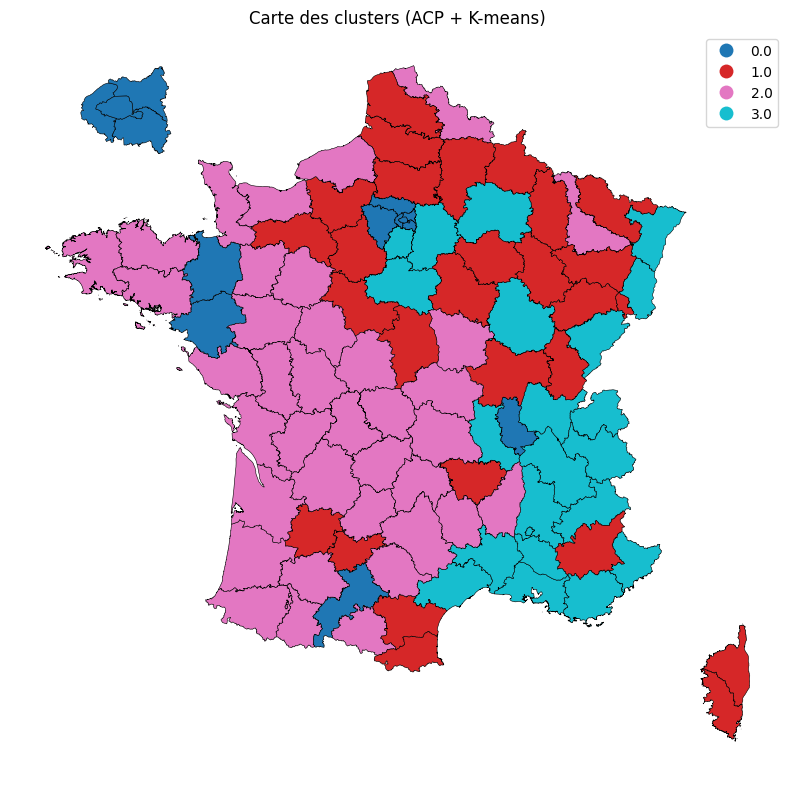

In [40]:
df_clusters = pd.DataFrame({
    "code_dept": dept_labels.astype(str),
    "cluster": clusters
})

df_clusters["code_dept"] = df_clusters["code_dept"].apply(
    lambda x: x.zfill(2) if x not in ["2A", "2B"] else x
)

departement_borders = carti_download(
    values=["France"],
    crs=4326,
    borders="DEPARTEMENT",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022
)

for col in ["code", "INSEE_DEP", "DEP", "code_dep"]:
    if col in departement_borders.columns:
        col_dept = col
        break

departement_borders[col_dept] = departement_borders[col_dept].astype(str)

carte = departement_borders.merge(
    df_clusters,
    left_on=col_dept,
    right_on="code_dept",
    how="left"
)

carte["cluster"] = pd.Categorical(carte["cluster"], categories=sorted(carte["cluster"].dropna().unique()))

#carte 

fig, ax = plt.subplots(figsize=(10, 10))
carte.plot(
    column="cluster",
    cmap="tab10",               #mêmes couleurs que l'ACP+K-means pour les 4 clusters
    linewidth=0.4,
    edgecolor="black",
    legend=True,
    categorical=True,
    ax=ax
)
ax.set_title("Carte des clusters (ACP + K-means)")
ax.axis("off")
plt.show()

La cartographie des 4 groupes issus de la classification K-means met en évidence une structuration spatiale marquée des comportements électoraux au premier tour de l'élection présidentielle de 2022.

Le groupe 0 se concentre sur quelques départements à forte urbanisation, principalement en Île-de-France et sur la façade atlantique nord. Bien que numériquement restreint, il couvre des territoires à haute densité démographique, ce qui lui confère un poids électoral non négligeable.

Le groupe 1 présente la plus grande extension spatiale. Il s'étend selon une diagonale nord-est / sud, englobant de nombreux départements du centre du territoire ainsi que du pourtour méditerranéen. Sa cohérence géographique est notable et correspond aux départements pour lesquels le vote Le Pen est le plus surreprésenté par rapport à la moyenne nationale.

Le groupe 2 forme un bloc compact sur la façade ouest du territoire, des Pays de la Loire à la Nouvelle-Aquitaine. Cette homogénéité spatiale est cohérente avec le profil socio-économique de ces départements, majoritairement ruraux ou périurbains, au sein desquels le vote Lassalle est surreprésenté.

Le groupe 3 se déploie principalement sur la moitié est de la France, notamment dans les régions Auvergne-Rhône-Alpes, Bourgogne-Franche-Comté et Grand Est, formant un ensemble géographiquement continu.

De manière générale, la compacité spatiale des 4 groupes constitue un résultat notable : elle indique que la classification obtenue par une méthode purement statistique, sans aucune contrainte de contiguïté géographique, restitue néanmoins une géographie électorale structurée et territorialement cohérente.

# Composition des 4 groupes de départements (clusters)

In [41]:
#dataframe au propre
df_result = pd.DataFrame({
    "departement": dept_labels.astype(str),
    "cluster": clusters
})

#liste par cluster

for c in sorted(df_result["cluster"].unique()):
    print(f"\n Cluster {c}")
    print(df_result[df_result["cluster"] == c]["departement"].tolist())


 Cluster 0
['31', '35', '44', '69', '75', '78', '92', '93', '94', '95']

 Cluster 1
['02', '04', '08', '10', '11', '18', '2A', '2B', '27', '28', '39', '41', '43', '47', '52', '55', '57', '60', '61', '62', '66', '70', '71', '80', '82', '88', '89', '90']

 Cluster 2
['03', '07', '09', '12', '14', '15', '16', '17', '19', '22', '23', '24', '29', '32', '33', '36', '37', '40', '46', '48', '49', '50', '53', '54', '56', '58', '59', '63', '64', '65', '72', '76', '79', '81', '85', '86', '87']

 Cluster 3
['01', '05', '06', '13', '21', '25', '26', '30', '34', '38', '42', '45', '51', '67', '68', '73', '74', '77', '83', '84', '91']


# Identification des départements centraux

In [42]:
dele_2 = dele.select_dtypes(include="number")

# ajouter les clusters
dele_2["cluster"] = clusters
dele_2["departement"] = dept_labels.astype(str)

departements_centraux = {}

for c in sorted(dele_2["cluster"].unique()):
    cluster_filtre = dele_2[dele_2["cluster"] == c].copy()
    
    # centre du cluster
    centre = cluster_filtre.drop(columns=["cluster", "departement"]).mean()
    
    # distance à la moyenne (euclidienne)
    distances = cluster_filtre.drop(columns=["cluster", "departement"]).apply(
        lambda row: np.linalg.norm(row - centre), axis=1)
    
    # département le plus proche du centre
    idx_min = distances.idxmin()
    departement_central = cluster_filtre.loc[idx_min, "departement"]
    
    # stockage
    departements_centraux[c] = departement_central

# affichage des 4 résultats
for c, d in departements_centraux.items():
    print(f"Cluster {c} → département central : {d}")

Cluster 0 → département central : 94
Cluster 1 → département central : 89
Cluster 2 → département central : 16
Cluster 3 → département central : 42


Nous obtenons donc les résultats suivants pour les clusters : 

- Cluster 0 → département central : 94 — Val-de-Marne
- Cluster 1 → département central : 89 — Yonne
- Cluster 2 → département central : 16 — Charente
- Cluster 3 → département central : 42 — Loire



# Caractérisation des 4 groupes

In [43]:
# ajouter les clusters à la base
base["cluster"] = clusters.astype(object)

# calcul des moyennes par cluster
moyennes_clusters = base.groupby("cluster").mean(numeric_only=True)

# calcul de la moyenne globale
moyenne_globale = base.mean(numeric_only=True).to_frame().T  # .T pour transformer en ligne

# on peut donner un nom spécial à cette ligne
moyenne_globale.index = ["France_M"]

# concaténer la moyenne globale avec les moyennes par cluster
moyennes_clusters = pd.concat([moyenne_globale, moyennes_clusters])
moyennes_clusters = moyennes_clusters.round(2)
moyennes_clusters.style.format("{:.2f}").background_gradient(cmap="Blues")


print(moyennes_clusters)

          cs_agri  cs_arti  cs_cadr  cs_inte  cs_empl  cs_ouvr  P_infBac  \
France_M     2.00     6.75    14.56    24.92    27.75    22.80      0.51   
0            0.35     5.14    28.95    25.29    24.23    14.52      0.37   
1            2.01     6.71    11.02    24.05    28.82    26.05      0.56   
2            2.97     7.10    12.41    24.61    28.21    23.64      0.53   
3            1.06     6.97    16.20    26.46    27.20    20.94      0.48   

          P_sup1erC  Taux_chomage_2024  Med_nivvie  ...  ROUSSEL  LASSALLE  \
France_M       0.19               7.11    22052.19  ...     0.02      0.04   
0              0.35               6.93    24342.00  ...     0.02      0.02   
1              0.15               7.74    21286.07  ...     0.02      0.04   
2              0.17               6.64    21584.86  ...     0.03      0.05   
3              0.21               7.19    22806.67  ...     0.02      0.03   

          MELENCHON  LE PEN  ARTHAUD  DUPONT-AIGNAN  POUTOU  PECRESSE  JAD

# Descriptions électorale et socio-économique des 4 groupes

Le groupe 0 englobe notamment Paris et la petite couronne, Lyon, Toulouse, Nantes et Rennes. Pour les scores électoraux, et au sens de la norme euclidienne, le département central de ce groupe est le Val-de-Marne (94). C'est dans ce groupe que le vote Mélenchon est le plus élevé : 29% contre 20% en France métropolitaine. Il en est de même du vote Macron, 31% contre 27%. À l'inverse, le vote Le Pen mesuré est le plus faible, avec une sous-représentation de -11 points par rapport à la France métropolitaine. Dans ce groupe sont observés les niveaux de vie médian et rapport interdécile les plus forts. De plus, les parts de ménages fiscaux, des revenus d'activité, et de diplômés supérieurs au 1er cycle apparaissent également sensiblement plus élevées que la moyenne.

Le groupe 1 comprend notamment de nombreux départements du quart nord-est de la France. Le département central de ce groupe est l'Yonne (89). C'est dans ce groupe que le vote Le Pen est le plus sur-représenté (+6 points) et que le vote Macron est le plus sous-représenté (-3 points). C'est dans ces départements que les taux de chômage et de pauvreté sont nettement les plus élevés, avec le niveau de vie médian le plus faible. De plus, la part de diplômés inférieurs au Baccalauréat y est nettement la plus élevée.

La majorité des départements du groupe 2 se situent dans la moitié ouest de la France. Le département central de ce groupe est la Charente (16). Dans ce groupe, les votes Macron, Le Pen et Mélenchon se situent à peu près dans la moyenne nationale, tandis que le vote Lassalle est sur-représenté. Les taux de chômage et de pauvreté y sont les plus faibles. Il en est de même de la part des revenus d'activité. Ceci pourrait être mis en lien avec une possible sur-représentation des retraités dans ces départements souvent ruraux.

Le groupe 3 comporte de nombreux départements de la moitié est de la France. Le département central de ce groupe est la Loire (42). Dans ce groupe, le vote Macron est légèrement inférieur par rapport au groupe précédent, tandis que le vote Zemmour est sur-représenté. C'est dans ces départements que les parts de professions intermédiaires et des revenus d'activité sont les plus élevées.

# Conclusion

À partir des sites publics data.gouv.fr et insee.fr, nous avons constitué une base de données portant sur les 96 départements de France métropolitaine, comprenant 27 variables électorales et socio-économiques.

Sur la base des seules variables électorales, une ACP a permis d'identifier deux axes principaux concentrant environ 48 % de la variance totale. Le premier axe, qui explique 27 % de la variance, est principalement structuré par les votes Le Pen et Dupont-Aignan d'un côté, et les votes Mélenchon et Macron de l'autre. Il apparaît ainsi que les votes Macron et Mélenchon sont positivement associés sur ce premier axe, et négativement liés aux votes Le Pen et Dupont-Aignan. Le second axe, expliquant 21 % de la variance, oppose davantage les votes de gauche aux votes Zemmour. Nous avons ensuite procédé à une classification par la méthode des K-means, retenue pour sa simplicité d'implémentation, son efficacité sur des données en faible dimension et la nature bien séparée des groupes observés dans le plan factoriel. Le choix de k=4 classes a été motivé par la conjonction de deux critères : la méthode du coude, qui indique une inflexion notable à partir de k=4, et le score de silhouette, qui présente un maximum local à ce même seuil.

Une cartographie de ces 4 classes a été réalisée, et un département central a été identifié pour chacune d'elles. Ces 4 groupes apparaissent globalement compacts d'un point de vue géographique, ce qui est d'autant plus remarquable que la classification a été obtenue sans aucune contrainte de contiguïté spatiale. Les profils électoraux moyens par classe corroborent les résultats de l'ACP : les votes Macron et Mélenchon apparaissent positivement associés et inversement corrélés au vote Le Pen, le groupe 0 étant caractérisé par la prédominance des premiers et le groupe 1 par celle du second.

Enfin, la caractérisation socio-économique des 4 groupes a permis de répondre à notre interrogation initiale. Il apparaît que chaque groupe présente des spécificités sociales propres, particulièrement marquées pour les groupes 0 et 1. La part de diplômés inférieurs au baccalauréat, la proportion de cadres et le niveau de vie médian diffèrent sensiblement entre ces deux groupes, confirmant l'existence de liens entre dynamiques électorales et structures socio-économiques territoriales.